<a href="https://colab.research.google.com/github/rashidkisejjere0784/Getting-started-with-mechanistic-interpretability-PyconAfrica-2026/blob/main/transformer_lens_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TransformerLens for Absolute Beginners

## See what a real language model is doing, one small step at a time

This notebook uses **GPT-2 Small**, an already-trained language model. We will not build a transformer, train anything, or begin with equations.

We only need four ideas:

1. **Tokens:** the small text pieces the model receives.
2. **Predictions:** the possible next tokens and their probabilities.
3. **Cache:** a recording of internal activity made by TransformerLens.
4. **Intervention:** temporarily turning something off to test whether it matters.


# Install the packages

In [27]:
!pip install transformer-lens>=3.9.0 torch>=2.14.0 -q

In [28]:
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from transformer_lens.model_bridge import TransformerBridge
from transformer_lens.utilities.components_utils import get_act_name

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FIGURE_DIR = Path("figures") / "transformer_lens_beginner"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)


def finish_figure(filename: str) -> None:
    """Display a figure and save a clear copy for sharing in chat."""
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved visual: {path.resolve()}")


print(f"Device:          {DEVICE}")
print(f"PyTorch:         {torch.__version__}")
print(f"TransformerLens: {version('transformer-lens')}")

Device:          cpu
PyTorch:         2.11.0+cpu
TransformerLens: 4.0.0




## Load a small pretrained model

We will use **GPT-2 Small**:

- It predicts one token at a time.
- It has 12 transformer layers.
- Each layer has 12 attention heads.
- It's already pre-trained

In [29]:
model = TransformerBridge.boot_transformers("gpt2", device=DEVICE)
model.enable_compatibility_mode()
model.eval()

print("Model loaded.")
print(f"Layers:          {model.cfg.n_layers}")
print(f"Heads per layer: {model.cfg.n_heads}")
print(f"Model width:     {model.cfg.d_model}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.
Layers:          12
Heads per layer: 12
Model width:     768




## Tokenize a simple sentence

We will give GPT-2 this prompt:

> ** is a country whose capital is**

GPT-2 must guess what comes next. Before it can do that, text is split into **tokens**.

Position | Token ID | Exact token
---------|----------|------------
   0     |  50256   | '<|endoftext|>'
   1     |  28572   | 'France'
   2     |   318    | ' is'
   3     |   257    | ' a'
   4     |   1499   | ' country'
   5     |   3025   | ' whose'
   6     |   3139   | ' capital'
   7     |   318    | ' is'


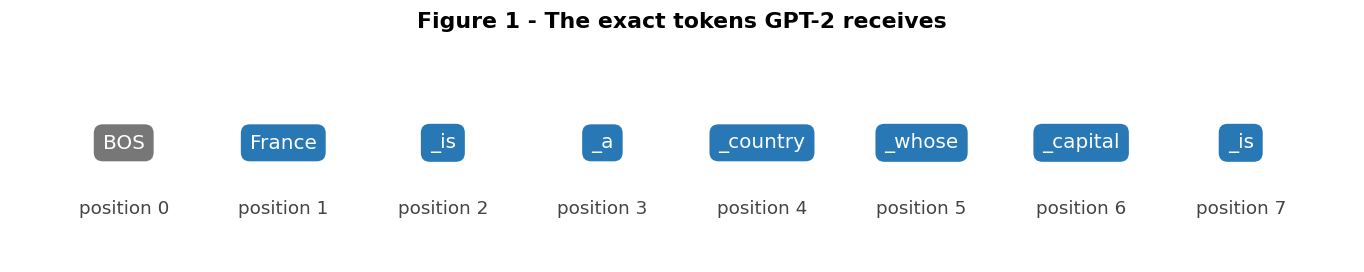

Saved visual: /content/figures/transformer_lens_beginner/01_tokens.png


In [43]:
PROMPT = "France is a country whose capital is"
tokens = model.to_tokens(PROMPT)
raw_token_labels = model.to_str_tokens(tokens)


def make_token_visible(token: str) -> str:
    """Show leading spaces and give the special first token a friendly name."""
    if token == model.tokenizer.bos_token:
        return "BOS"
    return token.replace(" ", "_")


visible_token_labels = [make_token_visible(token) for token in raw_token_labels]

print("Position | Token ID | Exact token")
print("---------|----------|------------")
for position, (token_id, token_text) in enumerate(
    zip(tokens[0].tolist(), raw_token_labels)
):
    print(f"{position:^8} | {token_id:^8} | {token_text!r}")

fig, ax = plt.subplots(figsize=(11.5, 2.4))
for position, label in enumerate(visible_token_labels):
    color = "#777777" if position == 0 else "#2878B5"
    ax.text(
        position,
        0,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=12,
        bbox={"boxstyle": "round,pad=0.45", "facecolor": color, "edgecolor": "none"},
    )
    ax.text(position, -0.48, f"position {position}", ha="center", color="#444444")

ax.set_xlim(-0.7, len(visible_token_labels) - 0.3)
ax.set_ylim(-0.8, 0.65)
ax.axis("off")
ax.set_title("Figure 1 - The exact tokens GPT-2 receives", pad=12)
finish_figure("01_tokens.png")



## Run the model and cache its activations

Normally we ask a model only for its output. TransformerLens can also record internal activity:

```python
logits, cache = model.run_with_cache(tokens)
```

That one line is the main reason TransformerLens is useful.

- **`logits`** are the model's raw scores for possible next tokens.
- **`cache`** is a dictionary-like recording of internal tensors.

Think of the cache as security-camera footage from many locations inside the model. Recording something does not yet explain it, but it gives us something concrete to inspect.

In [44]:
with torch.inference_mode():
    logits, cache = model.run_with_cache(tokens)

first_attention_name = get_act_name("pattern", 0)

print(f"Logits shape:    {tuple(logits.shape)}")
print("                 (batch, input position, possible next token)")
print(f"Cached tensors:  {len(cache)}")
print(f"Example cache key: {first_attention_name!r}")
print(f"Its shape:       {tuple(cache[first_attention_name].shape)}")
print("                 (batch, attention head, destination, source)")

Logits shape:    (1, 8, 50257)
                 (batch, input position, possible next token)
Cached tensors:  493
Example cache key: 'blocks.0.attn.hook_pattern'
Its shape:       (1, 12, 8, 8)
                 (batch, attention head, destination, source)




## Display the model's next-token predictions

The model produces 50,257 raw scores at every position. We care about the scores after the final `_is` token because those scores predict the next token.

**Softmax** converts the raw scores, called **logits**, into probabilities that sum to 100%.

Rank | Next token | Probability
-----|------------|------------
 1   | ' Paris'   |     28.80%
 2   | ' the'     |      5.98%
 3   | ' located' |      3.07%
 4   | ' Marse'   |      2.47%
 5   | ' France'  |      2.44%
 6   | ' in'      |      2.28%
 7   | ' a'       |      2.13%
 8   | ' not'     |      1.81%
 9   | ' on'      |      1.40%
 10  | ' Lyon'    |      1.21%


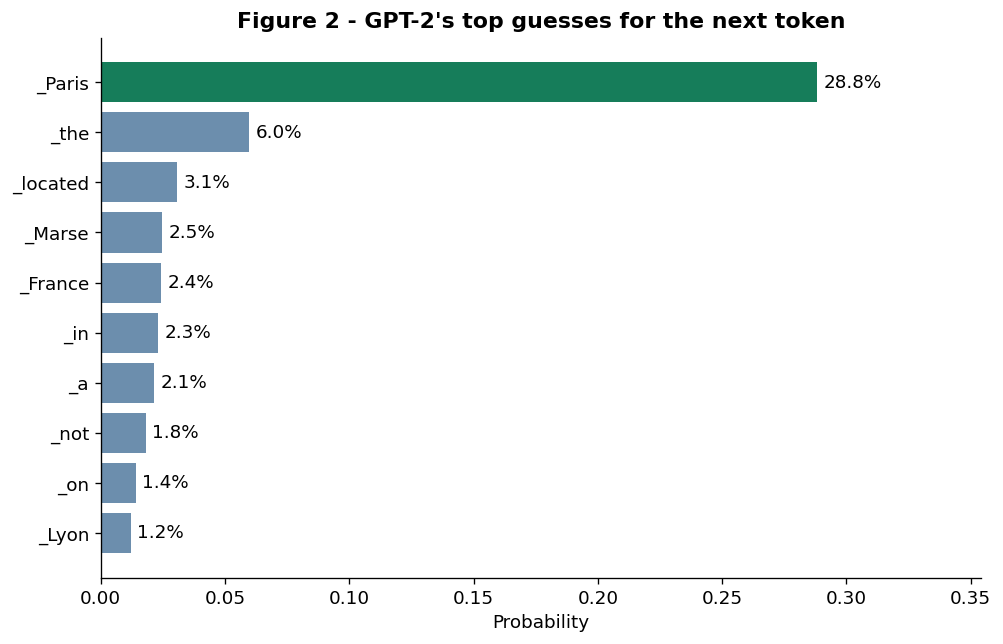

Saved visual: /content/figures/transformer_lens_beginner/02_next_token_predictions.png


In [45]:
final_probabilities = torch.softmax(logits[0, -1], dim=-1)
top_probabilities, top_token_ids = final_probabilities.topk(10)
top_token_labels = model.to_str_tokens(top_token_ids)

print("Rank | Next token | Probability")
print("-----|------------|------------")
for rank, (token_text, probability) in enumerate(
    zip(top_token_labels, top_probabilities.tolist()),
    start=1,
):
    print(f"{rank:^4} | {token_text!r:<10} | {probability:>10.2%}")

plot_labels = [make_token_visible(token) for token in top_token_labels]
plot_values = top_probabilities.detach().cpu().tolist()
bar_colors = ["#167D5A" if token == " Paris" else "#6C8EAD" for token in top_token_labels]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.barh(range(len(plot_labels)), plot_values, color=bar_colors)
ax.set_yticks(range(len(plot_labels)), plot_labels)
ax.invert_yaxis()
ax.bar_label(bars, labels=[f"{value:.1%}" for value in plot_values], padding=4)
ax.set_xlim(0, max(plot_values) * 1.23)
ax.set_xlabel("Probability")
ax.set_title("Figure 2 - GPT-2's top guesses for the next token")
finish_figure("02_next_token_predictions.png")



## 6. Visualize one attention head

An **attention head** decides how strongly each token position reads from earlier token positions.

Figure 3 is a map:

- Each **row** is a token doing the reading.
- Each **column** is a token being looked at.
- Darker blue means more attention.
- A row adds up to 1.00.
- Blank upper-right cells are future tokens that were unavailable at that moment.

We will inspect **layer 1, head 7**. The human-friendly numbers start at 1; Python stores them as layer `0`, head `6`.


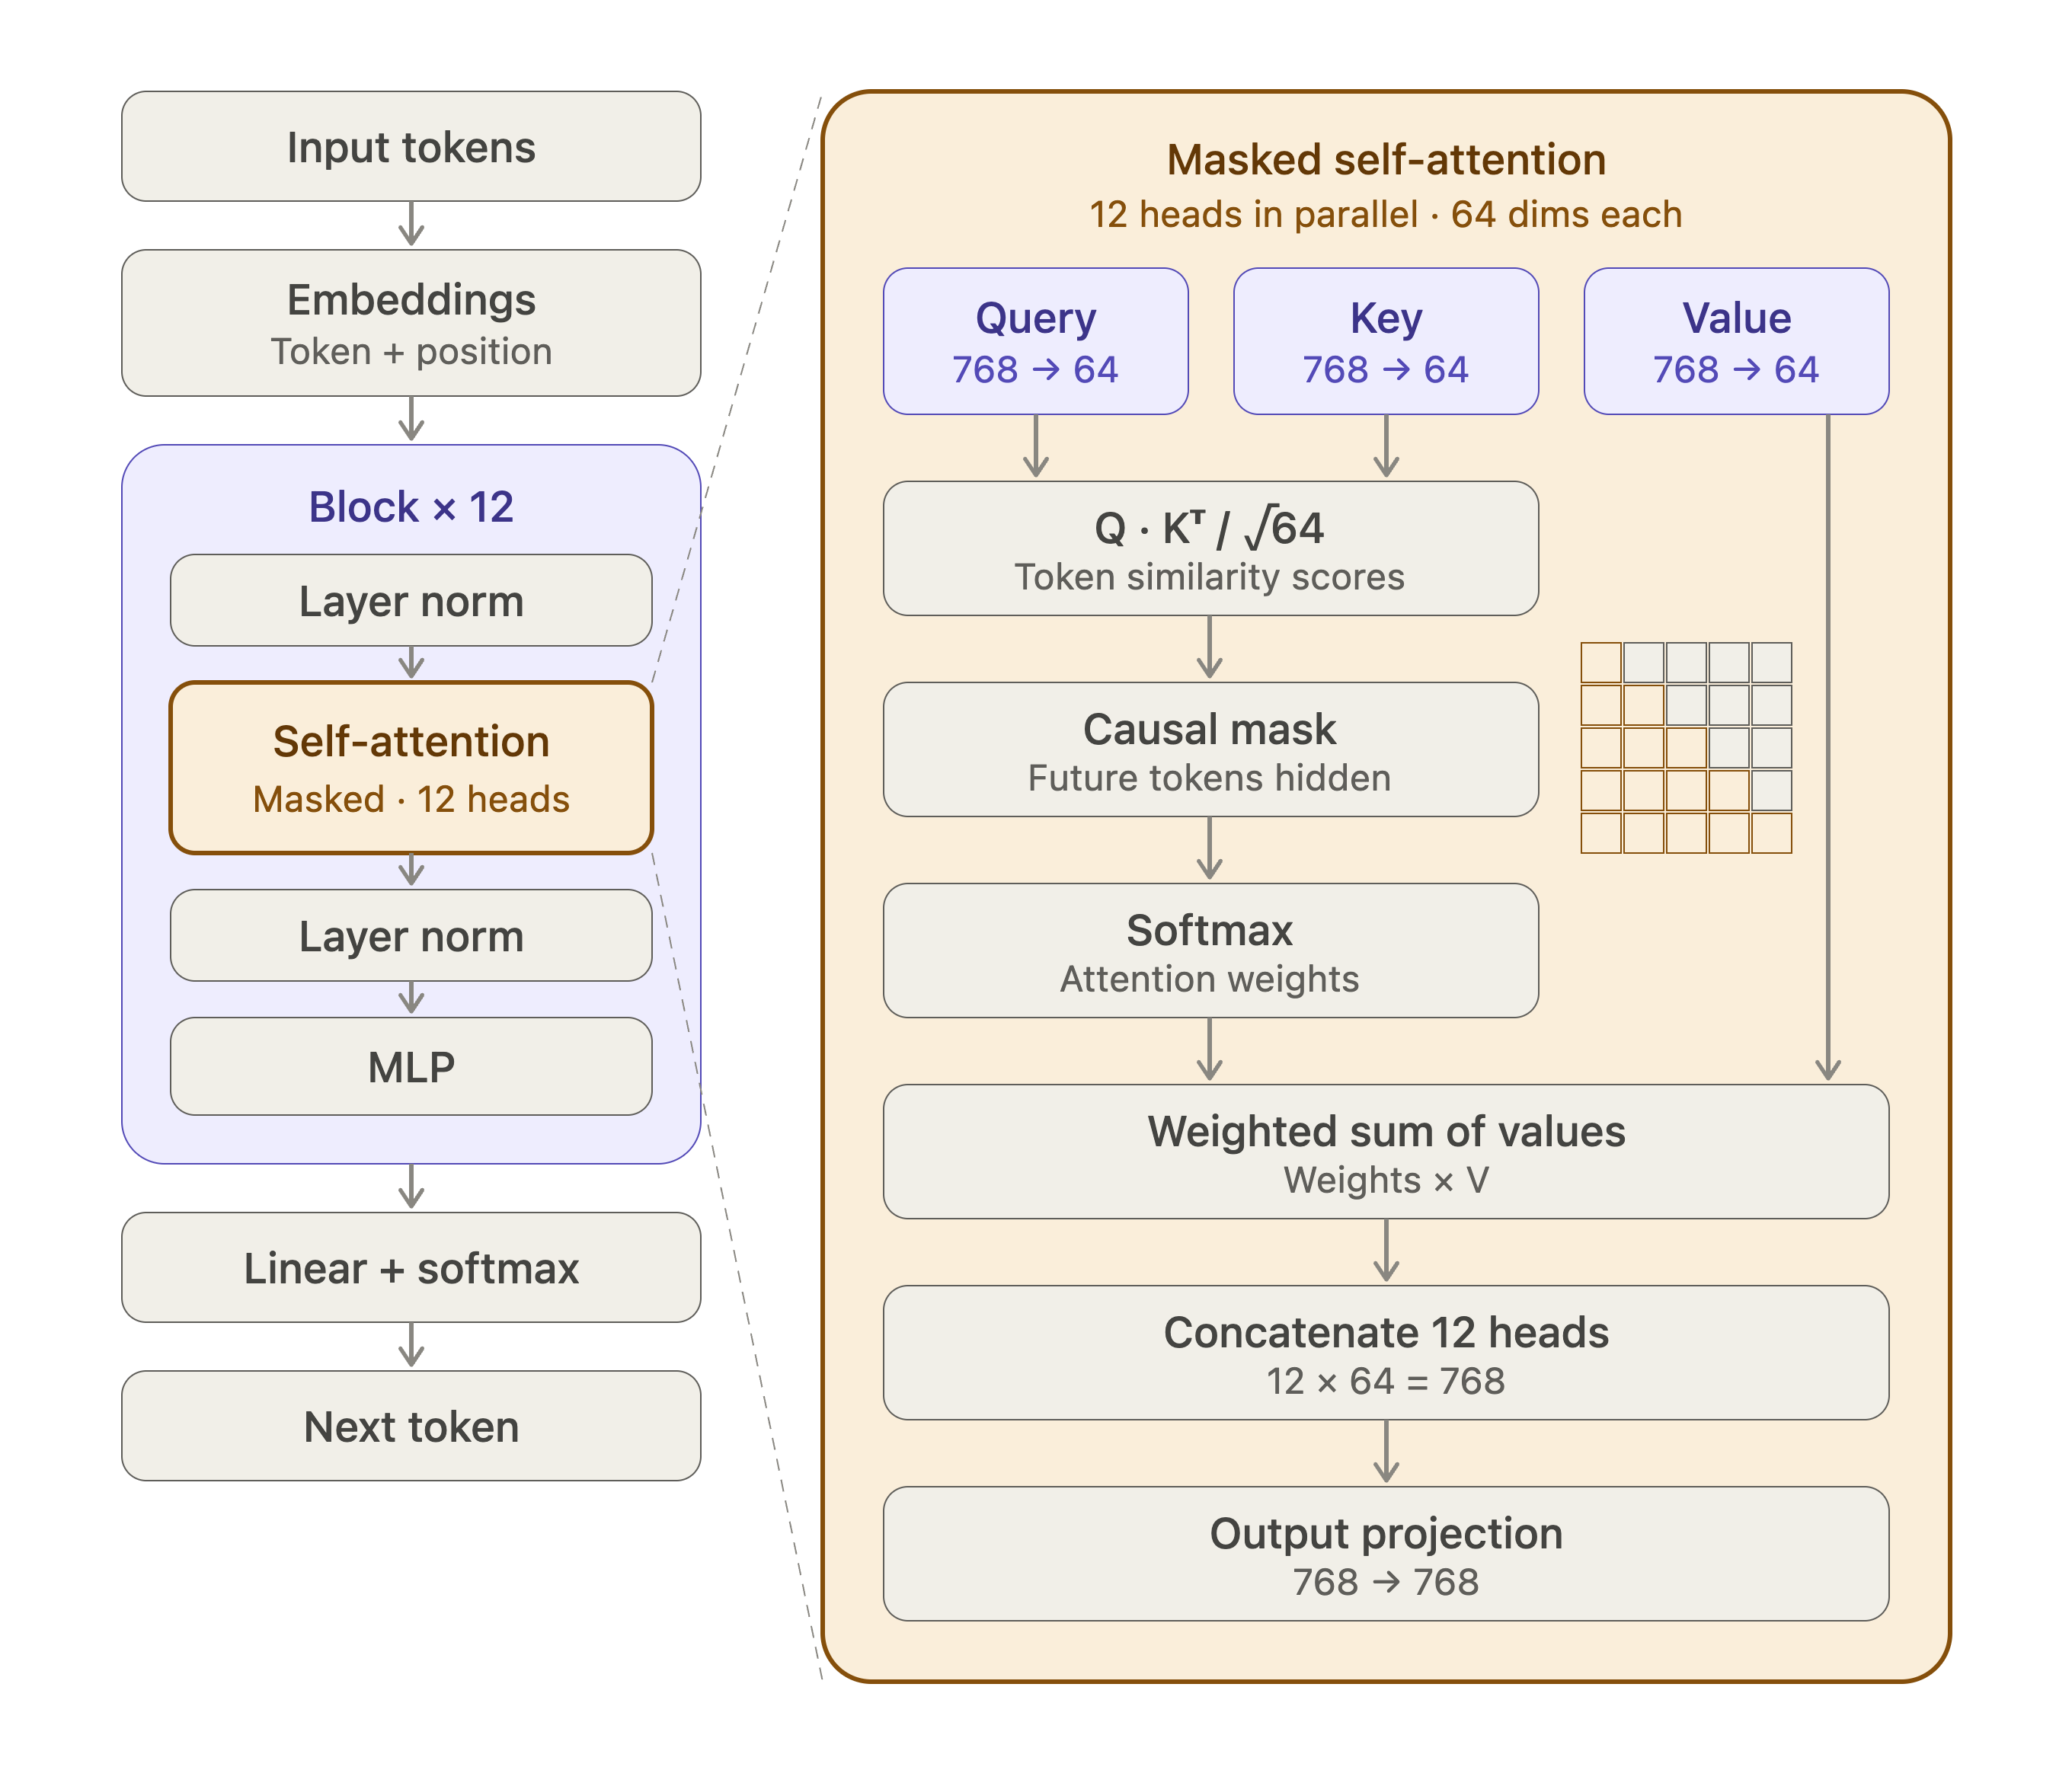

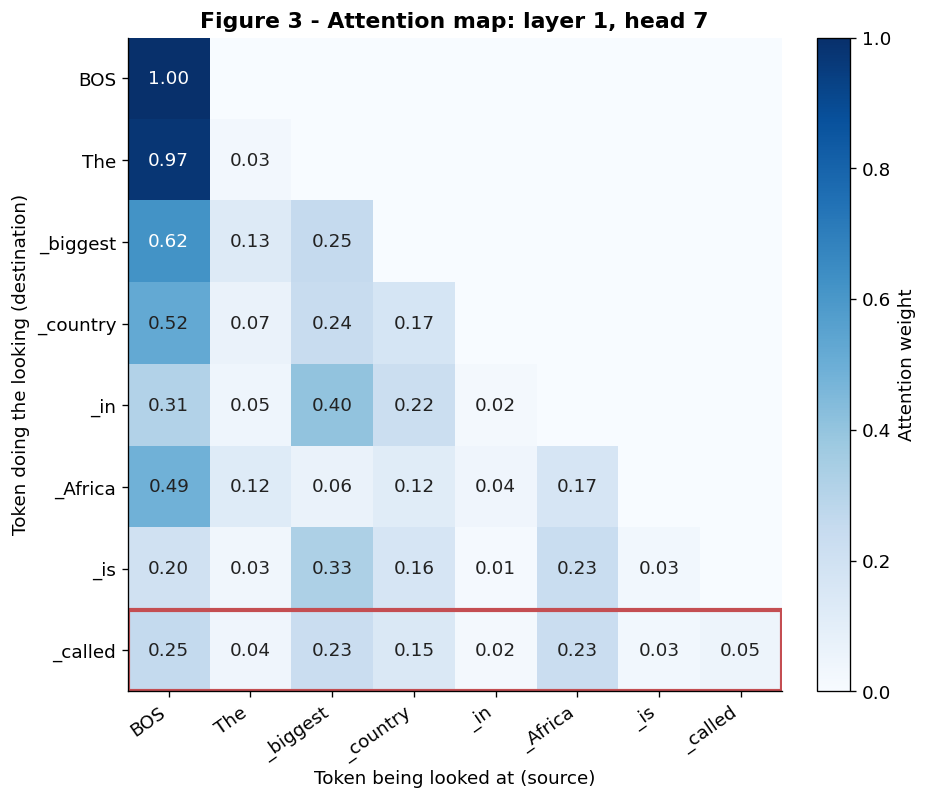

Saved visual: /content/figures/transformer_lens_beginner/03_single_attention_head.png
The final token's three strongest attention destinations:
        BOS: 0.255
    _Africa: 0.229
   _biggest: 0.229


In [33]:
DISPLAY_LAYER = 0  # Python counts from 0, so this is layer 1.
DISPLAY_HEAD = 6   # Python counts from 0, so this is head 7.

attention_pattern = cache[get_act_name("pattern", DISPLAY_LAYER)][
    0, DISPLAY_HEAD
].detach().cpu()

fig, ax = plt.subplots(figsize=(8.5, 6.8))
image = ax.imshow(attention_pattern, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(visible_token_labels)), visible_token_labels, rotation=35, ha="right")
ax.set_yticks(range(len(visible_token_labels)), visible_token_labels)
ax.set_xlabel("Token being looked at (source)")
ax.set_ylabel("Token doing the looking (destination)")
ax.set_title("Figure 3 - Attention map: layer 1, head 7")

for destination in range(len(visible_token_labels)):
    for source in range(destination + 1):
        value = attention_pattern[destination, source].item()
        text_color = "white" if value > 0.55 else "#222222"
        ax.text(source, destination, f"{value:.2f}", ha="center", va="center", color=text_color)

# Outline the final row because it is the row used while predicting the next token.
ax.add_patch(
    plt.Rectangle(
        (-0.5, len(visible_token_labels) - 1.5),
        len(visible_token_labels),
        1,
        fill=False,
        edgecolor="#C44E52",
        linewidth=2.5,
    )
)
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Attention weight")
finish_figure("03_single_attention_head.png")

final_row = attention_pattern[-1]
print("The final token's three strongest attention destinations:")
for source in final_row.argsort(descending=True)[:3].tolist():
    print(f"  {visible_token_labels[source]:>9s}: {final_row[source].item():.3f}")

### How to read Figure 3

Focus on the red-outlined final row because the model uses that position to predict what comes next.

For layer 1, head 7, the final `_is` token places its largest attention weight on:

1. `France` (about 0.36)
2. `_capital` (about 0.21)
3. `BOS` (about 0.15)

That is an interesting clue: this head looks toward words relevant to the answer.

### The most important warning in this notebook

> **Looking at `France` does not prove that this head caused the `Paris` prediction.**

The attention map shows **where the head reads**, but not what information it carries or whether the rest of the model uses it. We will test causality after exploring a few other heads.

---

## 7. Compare attention across layers and heads

GPT-2 Small has $12 \times 12 = 144$ attention heads. They do not all have the same pattern.

The helper below lets you inspect any one of them without touching the cache code. Give it human-friendly numbers from 1 to 12:

```python
show_attention(layer_number=6, head_number=6)
```

Change either number and rerun the cell. Figure 4 will update and a PNG for that choice will be saved.

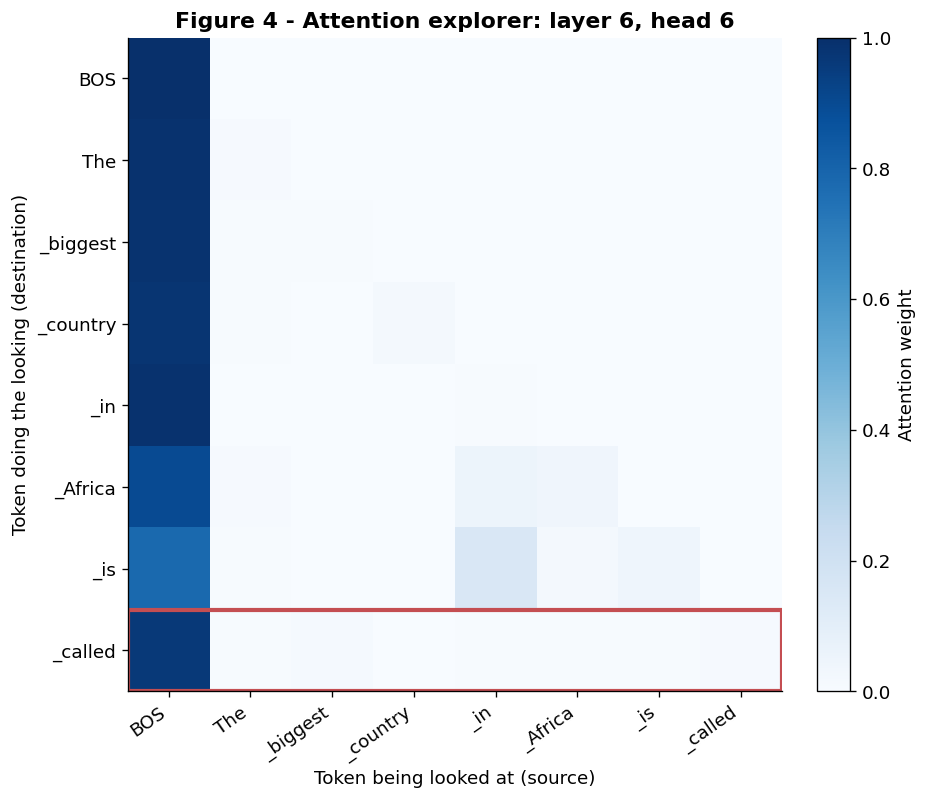

Saved visual: /content/figures/transformer_lens_beginner/04_attention_layer_6_head_6.png
Strongest source for the final token: 'BOS' (0.961)


In [34]:
def show_attention(layer_number: int = 6, head_number: int = 6) -> None:
    """Show one cached attention pattern using friendly 1-based numbers."""
    if not 1 <= layer_number <= model.cfg.n_layers:
        raise ValueError(f"layer_number must be between 1 and {model.cfg.n_layers}")
    if not 1 <= head_number <= model.cfg.n_heads:
        raise ValueError(f"head_number must be between 1 and {model.cfg.n_heads}")

    layer_index = layer_number - 1
    head_index = head_number - 1
    pattern = cache[get_act_name("pattern", layer_index)][0, head_index].detach().cpu()

    fig, ax = plt.subplots(figsize=(8.5, 6.8))
    image = ax.imshow(pattern, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(
        range(len(visible_token_labels)),
        visible_token_labels,
        rotation=35,
        ha="right",
    )
    ax.set_yticks(range(len(visible_token_labels)), visible_token_labels)
    ax.set_xlabel("Token being looked at (source)")
    ax.set_ylabel("Token doing the looking (destination)")
    ax.set_title(f"Figure 4 - Attention explorer: layer {layer_number}, head {head_number}")
    ax.add_patch(
        plt.Rectangle(
            (-0.5, len(visible_token_labels) - 1.5),
            len(visible_token_labels),
            1,
            fill=False,
            edgecolor="#C44E52",
            linewidth=2.5,
        )
    )
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Attention weight")
    finish_figure(f"04_attention_layer_{layer_number}_head_{head_number}.png")

    final_attention = pattern[-1]
    strongest_source = final_attention.argmax().item()
    print(
        "Strongest source for the final token: "
        f"{visible_token_labels[strongest_source]!r} "
        f"({final_attention[strongest_source].item():.3f})"
    )


show_attention(layer_number=6, head_number=6)



## A simple causal test: turn attention off

Now we perform an **intervention**. We run the same prompt three ways:

1. Normal model.
2. Only the displayed head (layer 1, head 7) is set to zero.
3. All 12 attention heads in layer 1 are set to zero.

The model's learned weights are not deleted or retrained. TransformerLens applies the change only during that forward pass.

### Exactly what “ON” and “OFF” mean

An attention head is **ON** during an ordinary forward pass. Its output continues to the rest of the model unchanged:

**ON**:  tokens -> head computes output z -> rest of model


 **OFF** means a **zero ablation**.

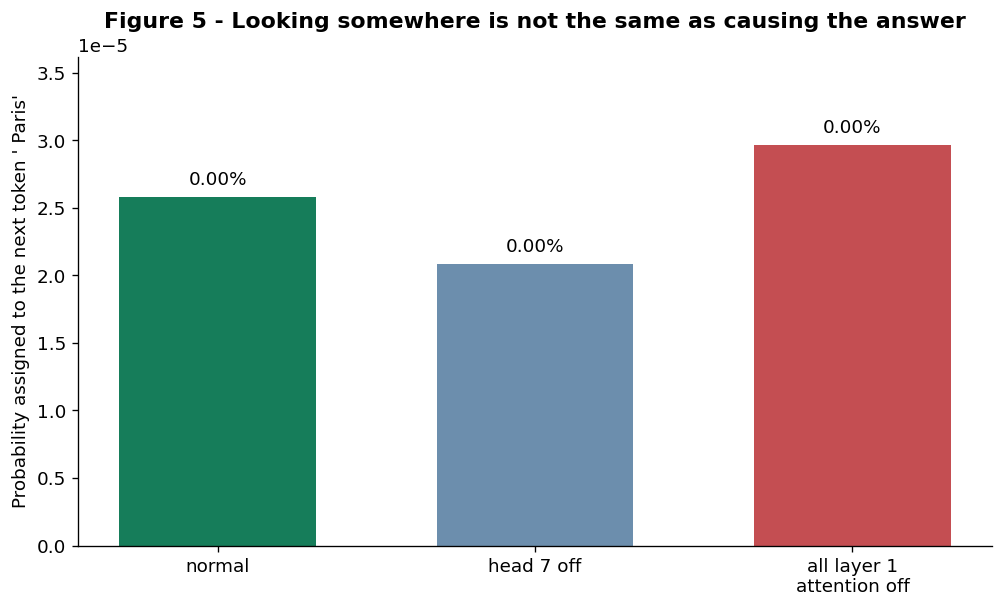

Saved visual: /content/figures/transformer_lens_beginner/05_attention_ablation.png
Layer 1 head-output tensor shape: (1, 8, 12, 64)
                                  batch, position, head, head dimension

Switch settings used:
  []                 -> all 12 heads ON (normal run; no hook)
  [7]                -> only head 7 OFF
  list(range(1, 13)) -> all 12 heads in layer 1 OFF
  [] after hooks     -> all heads ON again: True

Top prediction in each run:
  normal                     -> ' the' (6.17%)
  head 7 off                 -> ' Ethiopia' (6.75%)
  all layer 1 attention off  -> ',' (5.74%)


In [35]:
TARGET_TOKEN = " Paris"
TARGET_TOKEN_ID = model.to_single_token(TARGET_TOKEN)


def run_with_heads_off(
    input_tokens: torch.Tensor,
    layer_number: int,
    head_numbers: list[int],
) -> torch.Tensor:
    """Run the model with chosen heads temporarily switched off."""
    if not 1 <= layer_number <= model.cfg.n_layers:
        raise ValueError(f"layer_number must be between 1 and {model.cfg.n_layers}")

    invalid_heads = [
        head for head in head_numbers if not 1 <= head <= model.cfg.n_heads
    ]
    if invalid_heads:
        raise ValueError(
            f"Every head number must be between 1 and {model.cfg.n_heads}; "
            f"received {invalid_heads}"
        )

    # An empty list means every head stays ON: run the model normally.
    if not head_numbers:
        return model(input_tokens)

    layer_index = layer_number - 1
    head_indices = [head - 1 for head in head_numbers]
    head_output_name = get_act_name("z", layer_index)

    def switch_off_selected_heads(
        head_outputs: torch.Tensor,
        hook,
    ) -> torch.Tensor:
        # z has shape: (batch, token position, head, head dimension).
        changed_outputs = head_outputs.clone()
        changed_outputs[:, :, head_indices, :] = 0
        return changed_outputs

    # The hook exists only during this call and is removed automatically afterward.
    return model.run_with_hooks(
        input_tokens,
        fwd_hooks=[(head_output_name, switch_off_selected_heads)],
    )


with torch.inference_mode():
    normal_logits = run_with_heads_off(tokens, layer_number=1, head_numbers=[])
    head_off_logits = run_with_heads_off(tokens, layer_number=1, head_numbers=[7])
    layer_off_logits = run_with_heads_off(
        tokens,
        layer_number=1,
        head_numbers=list(range(1, 13)),
    )
    heads_back_on_logits = run_with_heads_off(
        tokens,
        layer_number=1,
        head_numbers=[],
    )

# A no-hook run after the interventions must exactly restore the normal result.
heads_restored = torch.allclose(normal_logits, heads_back_on_logits, atol=1e-6)
assert heads_restored

normal_probabilities = torch.softmax(normal_logits[0, -1], dim=-1)
head_off_probabilities = torch.softmax(head_off_logits[0, -1], dim=-1)
layer_off_probabilities = torch.softmax(layer_off_logits[0, -1], dim=-1)
probability_runs = [
    normal_probabilities,
    head_off_probabilities,
    layer_off_probabilities,
]
condition_labels = ["normal", "head 7 off", "all layer 1\nattention off"]
paris_probabilities = [
    probabilities[TARGET_TOKEN_ID].item() for probabilities in probability_runs
]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(
    condition_labels,
    paris_probabilities,
    color=["#167D5A", "#6C8EAD", "#C44E52"],
    width=0.62,
)
ax.bar_label(
    bars,
    labels=[f"{probability:.2%}" for probability in paris_probabilities],
    padding=5,
)
ax.set_ylim(0, max(paris_probabilities) * 1.22)
ax.set_ylabel("Probability assigned to the next token ' Paris'")
ax.set_title("Figure 5 - Looking somewhere is not the same as causing the answer")
finish_figure("05_attention_ablation.png")

head_output_shape = tuple(cache[get_act_name("z", 0)].shape)
print(f"Layer 1 head-output tensor shape: {head_output_shape}")
print("                                  batch, position, head, head dimension")
print("\nSwitch settings used:")
print("  []                 -> all 12 heads ON (normal run; no hook)")
print("  [7]                -> only head 7 OFF")
print("  list(range(1, 13)) -> all 12 heads in layer 1 OFF")
print(f"  [] after hooks     -> all heads ON again: {heads_restored}")

print("\nTop prediction in each run:")
for condition, probabilities in zip(condition_labels, probability_runs):
    top_id = probabilities.argmax().reshape(1)
    top_text = model.to_str_tokens(top_id)[0]
    top_probability = probabilities[top_id.item()].item()
    print(f"  {condition.replace(chr(10), ' '):26s} -> {top_text!r} ({top_probability:.2%})")

### Head switch playground

Change only `SWITCH_LAYER` and `HEADS_OFF`, then rerun the next cell.

- `HEADS_OFF = []` keeps every head ON.
- `HEADS_OFF = [7]` turns head 7 OFF.
- `HEADS_OFF = [7, 10]` turns heads 7 and 10 OFF together.

The numbers are human-friendly: layer 1 and head 1 are written as `1`, not `0`.

In [36]:
# Change these two settings.
SWITCH_LAYER = 1
HEADS_OFF = [7]

with torch.inference_mode():
    switched_logits = run_with_heads_off(
        tokens,
        layer_number=SWITCH_LAYER,
        head_numbers=HEADS_OFF,
    )

switched_probabilities = torch.softmax(switched_logits[0, -1], dim=-1)
switched_top_id = switched_probabilities.argmax().reshape(1)
switched_top_token = model.to_str_tokens(switched_top_id)[0]
switched_paris_probability = switched_probabilities[TARGET_TOKEN_ID].item()

status = "all heads ON" if not HEADS_OFF else f"heads {HEADS_OFF} OFF"
print(f"Layer {SWITCH_LAYER}: {status}")
print(f"Top next token: {switched_top_token!r}")
print(f"Probability of ' Paris': {switched_paris_probability:.2%}")
print("The switch is temporary; the next normal model run has every head ON.")

Layer 1: heads [7] OFF
Top next token: ' Ethiopia'
Probability of ' Paris': 0.00%
The switch is temporary; the next normal model run has every head ON.


---

## 9. Trace which head or layer affects `Paris` the most

Instead of choosing one head by looking at an attention map, we can test **every head**.

The experiment is:

```text
1. Run normally and record P([word]).
2. Turn off exactly one head.
3. Run again and record P([word]).
4. Repeat for all 144 heads.
5. Rank heads by how much the probability fell.
```


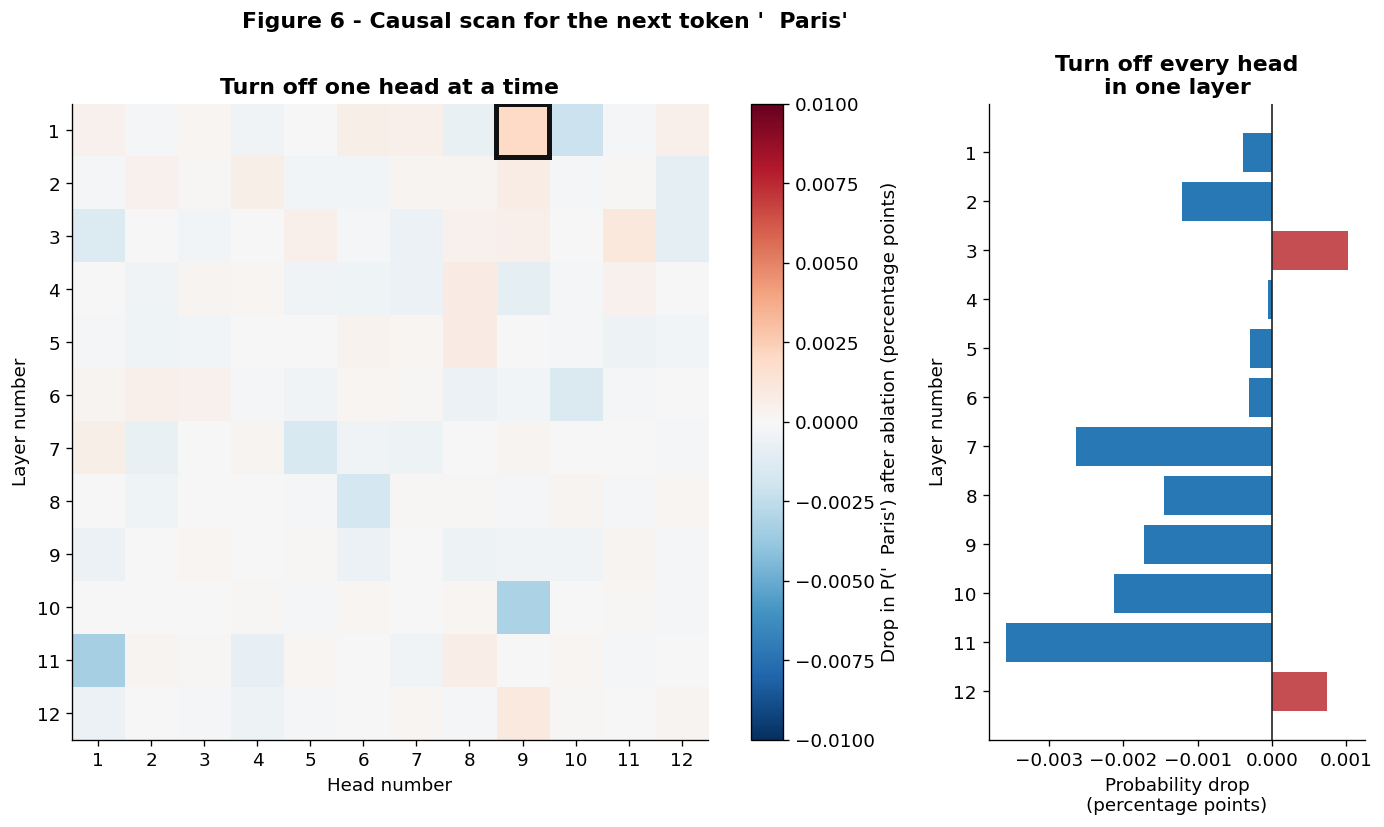

Saved visual: /content/figures/transformer_lens_beginner/06_head_and_layer_causal_scan.png
Normal P('  Paris'): 0.00%

Top 10 individually supportive heads:
Rank | Head  | Probability drop | Logit drop
-----|-------|------------------|-----------
 1   | L01H09 |          +0.00 pp |    -1.450
 2   | L03H11 |          +0.00 pp |    +0.109
 3   | L12H09 |          +0.00 pp |    +0.008
 4   | L04H08 |          +0.00 pp |    +0.114
 5   | L05H08 |          +0.00 pp |    +0.037
 6   | L02H09 |          +0.00 pp |    +0.240
 7   | L11H08 |          +0.00 pp |    +0.271
 8   | L02H04 |          +0.00 pp |    +0.222
 9   | L07H01 |          +0.00 pp |    +0.283
 10  | L01H06 |          +0.00 pp |    +0.170

Strongest individual supporter: layer 1, head 9
Strongest whole attention layer: layer 3 (+0.00 percentage points)


In [37]:
def trace_attention_components(
    input_tokens: torch.Tensor,
    target_token_id: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, float]:
    """Measure how much each head and each whole attention layer supports a token."""
    if input_tokens.shape[0] != 1:
        raise ValueError("This beginner scanner expects exactly one prompt.")

    number_of_layers = model.cfg.n_layers
    number_of_heads = model.cfg.n_heads

    baseline_logits = model(input_tokens)
    baseline_final_logits = baseline_logits[0, -1]
    baseline_probability = torch.softmax(baseline_final_logits, dim=-1)[
        target_token_id
    ]
    baseline_target_logit = baseline_final_logits[target_token_id]

    head_logit_drops = torch.empty(number_of_layers, number_of_heads)
    head_probability_drops = torch.empty(number_of_layers, number_of_heads)

    # One batch item per head lets us test all 12 heads in a layer at once.
    head_scan_tokens = input_tokens.repeat(number_of_heads, 1)
    for layer_index in range(number_of_layers):
        def zero_one_head_per_batch_item(
            head_outputs: torch.Tensor,
            hook,
        ) -> torch.Tensor:
            changed_outputs = head_outputs.clone()
            indices = torch.arange(number_of_heads, device=head_outputs.device)
            changed_outputs[indices, :, indices, :] = 0
            return changed_outputs

        ablated_logits = model.run_with_hooks(
            head_scan_tokens,
            fwd_hooks=[
                (get_act_name("z", layer_index), zero_one_head_per_batch_item)
            ],
        )
        ablated_final_logits = ablated_logits[:, -1]
        ablated_probabilities = torch.softmax(ablated_final_logits, dim=-1)[
            :, target_token_id
        ]
        head_logit_drops[layer_index] = (
            baseline_target_logit - ablated_final_logits[:, target_token_id]
        ).cpu()
        head_probability_drops[layer_index] = (
            baseline_probability - ablated_probabilities
        ).cpu()

    # Each batch item now has all heads disabled in one different layer.
    layer_scan_tokens = input_tokens.repeat(number_of_layers, 1)
    layer_hooks = []
    for layer_index in range(number_of_layers):
        def zero_one_layer_per_batch_item(
            head_outputs: torch.Tensor,
            hook,
            batch_index: int = layer_index,
        ) -> torch.Tensor:
            changed_outputs = head_outputs.clone()
            changed_outputs[batch_index, :, :, :] = 0
            return changed_outputs

        layer_hooks.append(
            (get_act_name("z", layer_index), zero_one_layer_per_batch_item)
        )

    layer_ablated_logits = model.run_with_hooks(
        layer_scan_tokens,
        fwd_hooks=layer_hooks,
    )[:, -1]
    layer_ablated_probabilities = torch.softmax(layer_ablated_logits, dim=-1)[
        :, target_token_id
    ]
    layer_logit_drops = (
        baseline_target_logit - layer_ablated_logits[:, target_token_id]
    ).cpu()
    layer_probability_drops = (
        baseline_probability - layer_ablated_probabilities
    ).cpu()

    return (
        head_logit_drops,
        head_probability_drops,
        layer_logit_drops,
        layer_probability_drops,
        baseline_probability.item(),
    )


with torch.inference_mode():
    (
        head_logit_drops,
        head_probability_drops,
        layer_logit_drops,
        layer_probability_drops,
        baseline_paris_probability,
    ) = trace_attention_components(tokens, TARGET_TOKEN_ID)

# Convert probability changes to percentage points for easier reading.
head_effect_points = 100 * head_probability_drops
layer_effect_points = 100 * layer_probability_drops
number_of_layers, number_of_heads = head_effect_points.shape

strongest_head_flat = head_effect_points.argmax().item()
strongest_head_layer, strongest_head_number = divmod(
    strongest_head_flat,
    number_of_heads,
)
strongest_layer = layer_effect_points.argmax().item()

fig, (ax_heads, ax_layers) = plt.subplots(
    1,
    2,
    figsize=(14, 7),
    gridspec_kw={"width_ratios": [4, 1.4]},
)
color_limit = max(head_effect_points.abs().max().item(), 0.01)
image = ax_heads.imshow(
    head_effect_points,
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
    aspect="equal",
)
ax_heads.set_xticks(range(number_of_heads), range(1, number_of_heads + 1))
ax_heads.set_yticks(range(number_of_layers), range(1, number_of_layers + 1))
ax_heads.set_xlabel("Head number")
ax_heads.set_ylabel("Layer number")
ax_heads.set_title("Turn off one head at a time")
ax_heads.add_patch(
    plt.Rectangle(
        (strongest_head_number - 0.5, strongest_head_layer - 0.5),
        1,
        1,
        fill=False,
        edgecolor="#111111",
        linewidth=3,
    )
)
colorbar = fig.colorbar(image, ax=ax_heads, fraction=0.046, pad=0.04)
colorbar.set_label(f"Drop in P(' {TARGET_TOKEN}') after ablation (percentage points)")

layer_colors = [
    "#C44E52" if effect >= 0 else "#2878B5"
    for effect in layer_effect_points.tolist()
]
layer_positions = torch.arange(1, number_of_layers + 1)
ax_layers.barh(layer_positions, layer_effect_points.tolist(), color=layer_colors)
ax_layers.axvline(0, color="#222222", linewidth=1)
ax_layers.invert_yaxis()
ax_layers.set_yticks(layer_positions.tolist())
ax_layers.set_xlabel("Probability drop\n(percentage points)")
ax_layers.set_ylabel("Layer number")
ax_layers.set_title("Turn off every head\nin one layer")

fig.suptitle(
    f"Figure 6 - Causal scan for the next token ' {TARGET_TOKEN}'",
    fontweight="bold",
)
finish_figure("06_head_and_layer_causal_scan.png")

print(f"Normal P(' {TARGET_TOKEN}'): {baseline_paris_probability:.2%}")
print("\nTop 10 individually supportive heads:")
print("Rank | Head  | Probability drop | Logit drop")
print("-----|-------|------------------|-----------")
for rank, flat_index in enumerate(
    torch.argsort(head_effect_points.flatten(), descending=True)[:10].tolist(),
    start=1,
):
    layer_index, head_index = divmod(flat_index, number_of_heads)
    print(
        f"{rank:^4} | L{layer_index + 1:02d}H{head_index + 1:02d} | "
        f"{head_effect_points[layer_index, head_index].item():>+14.2f} pp | "
        f"{head_logit_drops[layer_index, head_index].item():>+9.3f}"
    )

print(
    f"\nStrongest individual supporter: "
    f"layer {strongest_head_layer + 1}, head {strongest_head_number + 1}"
)
print(
    f"Strongest whole attention layer: layer {strongest_layer + 1} "
    f"({layer_effect_points[strongest_layer].item():+.2f} percentage points)"
)

In [38]:
# Clean summary using the behavioral metric defined above: change in P(" Paris").
most_supportive_flat = head_effect_points.argmax().item()
most_supportive_layer, most_supportive_head = divmod(
    most_supportive_flat,
    number_of_heads,
)
most_suppressive_flat = head_effect_points.argmin().item()
most_suppressive_layer, most_suppressive_head = divmod(
    most_suppressive_flat,
    number_of_heads,
)
most_important_layer = layer_effect_points.argmax().item()

supportive_drop = head_effect_points[
    most_supportive_layer,
    most_supportive_head,
].item()
suppressive_drop = head_effect_points[
    most_suppressive_layer,
    most_suppressive_head,
].item()
layer_drop = layer_effect_points[most_important_layer].item()

print("CAUSAL TRACE SUMMARY")
print(f"Normal P(' Paris'): {baseline_paris_probability:.2%}")
print(
    f"Strongest individual supporter: "
    f"L{most_supportive_layer + 1:02d}H{most_supportive_head + 1:02d}\n"
    f"  OFF probability: {baseline_paris_probability - supportive_drop / 100:.2%}\n"
    f"  Probability drop: {supportive_drop:+.2f} percentage points"
)
print(
    f"Strongest individual suppressor: "
    f"L{most_suppressive_layer + 1:02d}H{most_suppressive_head + 1:02d}\n"
    f"  OFF probability: {baseline_paris_probability - suppressive_drop / 100:.2%}\n"
    f"  Probability drop: {suppressive_drop:+.2f} percentage points"
)
print(
    f"Strongest whole attention layer: layer {most_important_layer + 1}\n"
    f"  OFF probability: {baseline_paris_probability - layer_drop / 100:.2%}\n"
    f"  Probability drop: {layer_drop:+.2f} percentage points"
)

CAUSAL TRACE SUMMARY
Normal P(' Paris'): 0.00%
Strongest individual supporter: L01H09
  OFF probability: 0.00%
  Probability drop: +0.00 percentage points
Strongest individual suppressor: L11H01
  OFF probability: 0.01%
  Probability drop: -0.00 percentage points
Strongest whole attention layer: layer 3
  OFF probability: 0.00%
  Probability drop: +0.00 percentage points


---

## 9. Your turn: try another prompt

Change `MY_PROMPT` below and rerun the cell. Keep the sentence short at first.

Good examples:

- `Germany is a country whose capital is`
- `The opposite of hot is`
- `One plus one equals`

Look at the exact token strings as well as the predictions. If you want attention maps for the new prompt, replace `PROMPT` earlier in the notebook and rerun from the tokenization section onward.

In [39]:
def predict_next(text: str, number_of_guesses: int = 5) -> None:
    """Print a short prompt's tokens and most likely next tokens."""
    input_ids = model.to_tokens(text)
    with torch.inference_mode():
        output_logits = model(input_ids)
    probabilities = torch.softmax(output_logits[0, -1], dim=-1)
    values, token_ids = probabilities.topk(number_of_guesses)

    print("Input tokens:", model.to_str_tokens(input_ids))
    print("\nTop next-token guesses:")
    for rank, (token_text, probability) in enumerate(
        zip(model.to_str_tokens(token_ids), values.tolist()),
        start=1,
    ):
        print(f"  {rank}. {token_text!r:<12} {probability:.2%}")


MY_PROMPT = "Germany is a country whose capital is"
predict_next(MY_PROMPT)

Input tokens: ['<|endoftext|>', 'Germany', ' is', ' a', ' country', ' whose', ' capital', ' is']

Top next-token guesses:
  1. ' Berlin'    17.72%
  2. ' the'       4.63%
  3. ' in'        3.88%
  4. ' located'   3.23%
  5. ' Munich'    2.78%
